**Проект**
Методы MLP и CatBoost

В этом проекте я сравниваю два метода машинного обучения для задачи предсказания цены дома по его характеристикам: нейронную сеть MLP и алгоритм градиентного бустинга CatBoost.

Часть 1. Регрессия цены дома с помощью MLP

MLP (Multilayer Perceptron) — это искусственная нейронная сеть прямого распространения.
Используется для регрессии, классификации, прогнозирования сложных нелинейных зависимостей.
Как работает:
входной слой получает признаки;
несколько скрытых слоёв — обучают сложные нелинейные зависимости;
выходной слой — даёт прогноз (SalePrice).

В этой части:
- Загружаем датасет Ames Housing;
- Готовим признаки (числовые + категориальные);
- Строим модель MLPRegressor (скрытые слои);
- Анализируем качество: метрики, кривая потерь, график "факт vs предсказание".


In [3]:
# Импорт основных библиотек

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


Здесь я подключаю все нужные библиотеки.
pandas и numpy — для работы с таблицами и числами,
matplotlib — для построения графиков,
модули из sklearn — для разбиения данных на выборки, предобработки признаков (масштабирование, кодирование категорий, заполнение пропусков), построения конвейера (pipeline), обучения нейронной сети MLP и вычисления метрик качества модели.

In [4]:
# 1. Загрузка и первичный осмотр данных
data = pd.read_csv("/content/AmesHousing.csv")

print("Размер данных:", data.shape)
display(data.head())



Размер данных: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


Здесь я загружаю датасет с информацией о домах из CSV-файла.

In [5]:
#2. Удаляем явно лишние идентификаторы
data = data.drop(columns=["Order", "PID"])

# Отбрасываем строки без целевой переменной на всякий случай
data = data.dropna(subset=["SalePrice"])

X = data.drop(columns=["SalePrice"])
y = data["SalePrice"]

X.shape, y.shape


((2930, 79), (2930,))

В этой ячейке я убираю технические столбцы-идентификаторы (например, Order, PID), которые не несут полезной информации для предсказания цены, такие поля могут мешать модели

In [6]:
# 3. Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((2344, 79), (586, 79))

Здесь я делю данные на две части:

обучающая выборка (train) — на ней модель учится;

тестовая выборка (test) — на ней я проверяю, как модель работает на новых данных.

Также я отделяю признаки (характеристики дома) от целевой переменной (цены).

In [7]:
#4. Определяем численные и категориальные признаки
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Числовых признаков:", len(numeric_features))
print("Категориальных признаков:", len(categorical_features))


Числовых признаков: 36
Категориальных признаков: 43


Здесь я делю все признаки на две группы:

числовые (площадь, количество комнат, год постройки и т.п.);

категориальные (район, тип дома, материал и т.д.).

In [8]:
#5.Препроцессинг
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)



В этой ячейке я настраиваю схему предобработки данных:

1) для числовых признаков — сначала заполняю пропуски (например, средним значением), затем привожу их к одному масштабу с помощью стандартизации;

2) для категориальных признаков — заполняю пропуски (например, самой частой категорией), а затем кодирую категории в числовой вид с помощью One-Hot Encoding.

Всё это объединяется в один объект preprocessor, чтобы потом автоматически применять одинаковую предобработку и к обучающим, и к тестовым данным.

In [9]:
#6. Применение предварительного обработчика (preprocessor)
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

X_train_prepared.shape, X_test_prepared.shape


((2344, 300), (586, 300))

Здесь я применяю подготовленный препроцессор к обучающей и тестовой выборке.
На выходе получаются уже преобразованные признаки в числовом виде, с которыми нейронная сеть может нормально работать. Это делается для удобства работы с моделью.

In [10]:
# 7. Построение и обучение модели MLP

# Импортируем модель
from sklearn.neural_network import MLPRegressor

# Создаём модель MLP
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64),   # два скрытых слоя по 128 и 64 нейрона
    activation="relu",              # ReLU обычно работает лучше всего
    solver="adam",                  # оптимизатор Adam — стандарт для нейросетей
    random_state=42,                # фиксируем зерно рандома для воспроизводимости
    max_iter=1000                    # увеличиваем количество итераций обучения
)

# Обучаем модель на подготовленных данных
mlp.fit(X_train_prepared, y_train)

# Проверим завершение обучения
print("MLP обучен. Число итераций:", mlp.n_iter_)


MLP обучен. Число итераций: 1000


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Здесь я создаю и обучаю модель MLP (многослойную нейронную сеть для регрессии).
В параметрах задаю количество скрытых слоёв и нейронов, функцию активации, количество итераций обучения и другие настройки.
Метод fit запускает процесс обучения: модель многократно проходит по обучающим данным, подстраивает свои веса и учится предсказывать цену дома по его признакам.

In [11]:
#8. Выполняем предсказания
y_pred = mlp.predict(X_test_prepared)

# Вычисляем метрики
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5   # <-- вручную
r2 = r2_score(y_test, y_pred)

# Вывод метрик
print(f"MAE  (средняя абсолютная ошибка): {mae:,.2f}")
print(f"RMSE (корень из MSE):             {rmse:,.2f}")
print(f"R²   (качество модели):           {r2:.3f}")


MAE  (средняя абсолютная ошибка): 16,042.06
RMSE (корень из MSE):             28,603.60
R²   (качество модели):           0.898


В этой ячейке я использую уже обученную модель, чтобы сделать предсказания цен на тестовой выборке.
Затем сравниваю предсказанные значения с реальными ценами и считаю метрики:

MAE — средняя абсолютная ошибка (насколько в среднем мы ошибаемся в деньгах);

RMSE — корень из средней квадратичной ошибки (сильнее штрафует большие ошибки);

R² — доля объяснённой вариации (насколько хорошо модель объясняет разброс цен).

По этим числам можно судить, насколько хорошо MLP справился с задачей.

Средняя абсолютная ошибка (MAE) составила примерно 16 тысяч долларов, значение RMSE составило около 29 тысяч долларов. Коэффициент детерминации R², равный 0.898, означает, что модель объясняет около 90% вариации целевой переменной, что является хорошим показателем качества. Таким образом, можно заключить, что построенная MLP-модель обладает устойчивой предсказательной способностью и в целом адекватно отражает зависимости между характеристиками домов и их рыночной стоимостью.

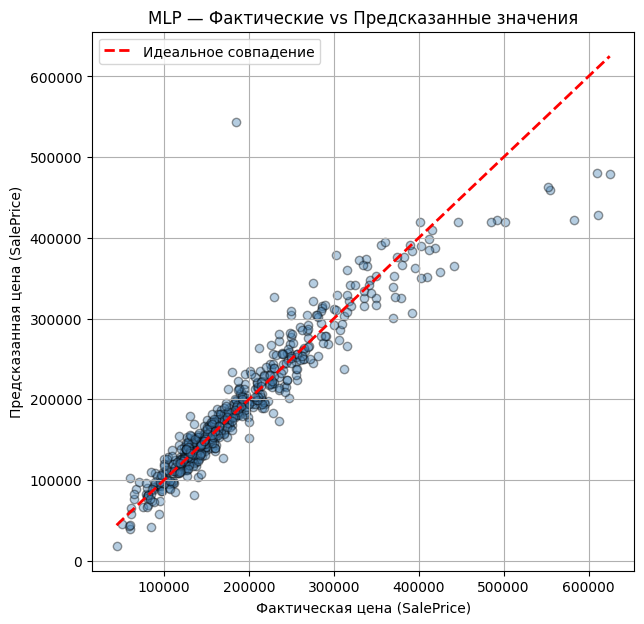

In [12]:
#9. Scatter-график: фактические значения против предсказанных
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.4, color="steelblue", edgecolors="k")

# Диагональная идеальная линия
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2,
    label="Идеальное совпадение"
)

plt.xlabel("Фактическая цена (SalePrice)")
plt.ylabel("Предсказанная цена (SalePrice)")
plt.title("MLP — Фактические vs Предсказанные значения")
plt.legend()
plt.grid(True)

plt.show()


Здесь я строю точечный график, где по оси X — реальные цены домов, а по оси Y — предсказанные моделью. По тому, как сильно точки отклоняются от диагонали, можно визуально оценить, где и насколько модель ошибается.

Ось X представляет собой фактические значения (реальные цены), а ось Y — предсказанные моделью значения. модель MLP демонстрирует хорошие результаты, так как большая часть точек лежит близко к идеальной линии. В правой части графика видно некоторое рассеяние, что может свидетельствовать об объектах с более высокими ценами, которые трудно предсказать.

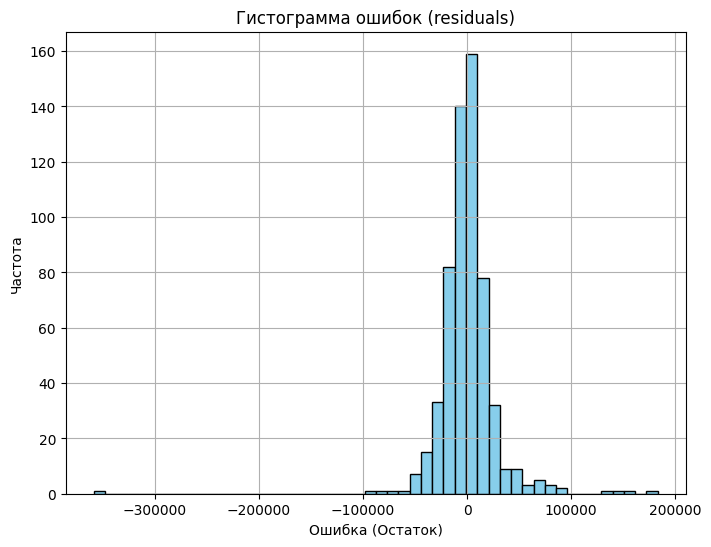

In [13]:
# 10. Гистограмма ошибок (residuals)

# Вычисляем остатки (ошибки) между фактическими и предсказанными значениями
residuals = y_test - y_pred

# Построение гистограммы остатков
plt.figure(figsize=(8, 6))  # Устанавливаем размер графика
plt.hist(residuals, bins=50, color='skyblue', edgecolor='black')  # Строим гистограмму с 50 корзинами
plt.title("Гистограмма ошибок (residuals)")  # Заголовок графика
plt.xlabel("Ошибка (Остаток)")  # Подпись оси X
plt.ylabel("Частота")  # Подпись оси Y
plt.grid(True)  # Включаем сетку для улучшения читаемости
plt.show()  # Отображаем график


Если модель в целом хорошая, ошибки должны быть более-менее симметрично распределены вокруг нуля, без огромных "хвостов".
Такой график помогает понять, есть ли систематические смещения (например, модель постоянно недооценивает дорогие дома).

Гистограмма показывает, что модель в целом предсказывает с небольшой ошибкой, и большинство предсказаний находятся близко к реальным значениям.

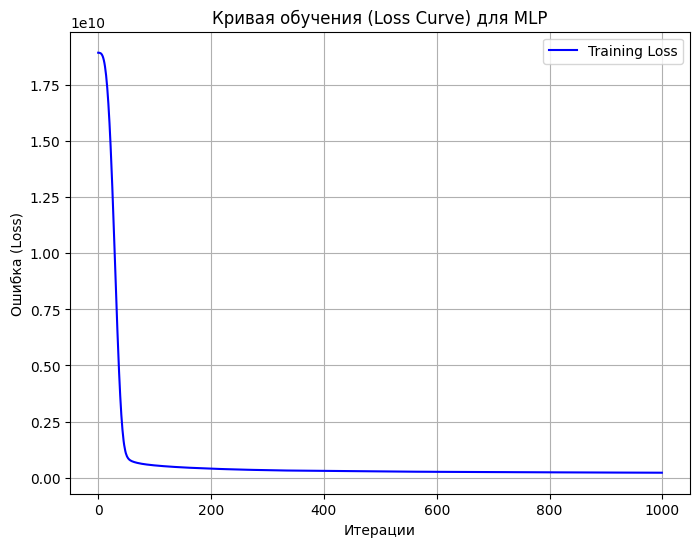

In [14]:
#11. Кривая обучения (Loss Curve)
# Построение кривой обучения для MLP
plt.figure(figsize=(8, 6))  # Устанавливаем размер графика
plt.plot(mlp.loss_curve_, label='Training Loss', color='blue')  # Строим кривую обучения
plt.title("Кривая обучения (Loss Curve) для MLP")  # Заголовок графика
plt.xlabel("Итерации")  # Подпись оси X
plt.ylabel("Ошибка (Loss)")  # Подпись оси Y
plt.grid(True)  # Включаем сетку для улучшения читаемости
plt.legend()  # Добавляем легенду
plt.show()  # Отображаем график

Здесь я строю график изменения функции потерь (ошибки) по эпохам обучения: отдельно для обучающей и, возможно, для валидационной выборки.
По этому графику можно увидеть, сходится ли обучение, не началось ли переобучение (когда ошибка на обучении падает, а на валидации растёт), и достаточно ли количества эпох.

Модель сходится очень быстро в начале и стабилизируется на низком уровне ошибки. Это свидетельствует о хорошем процессе обучения.

Часть 2. Регрессия цены дома с помощью CatBoost

CatBoost — это модель для регрессии, которая отлично подходит для табличных данных с большим количеством категориальных признаков и пропусков. Она даёт высокую точность и требует минимальной предобработки, поэтому выступает сильной альтернативой MLP.

В этой части:

* Загружаем датасет Ames Housing;
*  Готовим признаки (числовые и категориальные);
Строим модель CatBoostRegressor;
*   Строим модель CatBoostRegressor;
*   Оценка качества модели (метрики, графики).




In [15]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.8 MB/s eta 0:00:00


In [16]:
from catboost import CatBoostRegressor

Здесь я импортирую класс CatBoostRegressor — это модель градиентного бустинга по деревьям, которая особенно хорошо работает с табличными и категориальными данными.

In [17]:
# Обрабатываем NaN значения в категориальных признаках
for col in categorical_features:
    X_train[col] = X_train[col].fillna('missing')  # Заполняем NaN значением "missing"
    X_test[col] = X_test[col].fillna('missing')    # То же для тестовой выборки

В этой ячейке я заполняю пропуски в категориальных столбцах (например, строкой "Unknown" или чем-то подобным).
Это нужно, чтобы модель не "ломалась" на пустых значениях и могла корректно использовать все объекты при обучении.

In [18]:
# Преобразуем категориальные признаки в строковый тип
X_train[categorical_features] = X_train[categorical_features].astype(str)
X_test[categorical_features] = X_test[categorical_features].astype(str)

Здесь я привожу категориальные признаки к строковому типу (str).
CatBoost умеет автоматически работать с категориальными признаками, но ему важно, чтобы такие столбцы были именно строками, а не числами.
Так модель правильно понимает, что это категории, а не просто какие-то числовые значения.

In [19]:
# 12. Построение и обучение модели CatBoost

# Создаём модель CatBoost
catboost_model = CatBoostRegressor(
    iterations=1000,              # Количество итераций
    learning_rate=0.05,           # Скорость обучения
    depth=10,                     # Глубина деревьев
    cat_features=categorical_features,  # Указываем категориальные признаки
    random_state=42,              # Для воспроизводимости
    verbose=100                   # Печать прогресса каждые 100 итераций
)

# Обучаем модель CatBoost на подготовленных данных
catboost_model.fit(X_train, y_train)

# Проверим завершение обучения
print("CatBoost обучен.")


0:	learn: 74706.8785168	total: 197ms	remaining: 3m 16s
100:	learn: 17755.8377985	total: 20s	remaining: 2m 57s
200:	learn: 12949.8474867	total: 54.2s	remaining: 3m 35s
300:	learn: 9712.3372937	total: 1m 17s	remaining: 3m
400:	learn: 7501.7407628	total: 1m 41s	remaining: 2m 31s
500:	learn: 6262.1833307	total: 2m 5s	remaining: 2m 4s
600:	learn: 5216.1206168	total: 2m 28s	remaining: 1m 38s
700:	learn: 4352.5880333	total: 2m 52s	remaining: 1m 13s
800:	learn: 3685.3888016	total: 3m 17s	remaining: 49s
900:	learn: 3204.7849065	total: 3m 44s	remaining: 24.7s
999:	learn: 2815.9506046	total: 4m 9s	remaining: 0us
CatBoost обучен.


В этой ячейке я создаю и обучаю модель CatBoostRegressor.
Указываю, какие признаки являются категориальными, задаю основные параметры (глубина деревьев, количество итераций, скорость обучения и т.д.).
Метод fit запускает обучение: модель по очереди строит много решающих деревьев, каждое из которых исправляет ошибки предыдущих, постепенно улучшая качество предсказаний.

In [20]:
# 13. Оценка модели CatBoost

# Выполняем предсказания
y_pred_catboost = catboost_model.predict(X_test)

# Вычисляем метрики
mae_catboost = mean_absolute_error(y_test, y_pred_catboost)
rmse_catboost = mean_squared_error(y_test, y_pred_catboost) ** 0.5
r2_catboost = r2_score(y_test, y_pred_catboost)

# Вывод метрик
print(f"MAE  (средняя абсолютная ошибка): {mae_catboost:,.2f}")
print(f"RMSE (корень из MSE):             {rmse_catboost:,.2f}")
print(f"R²   (качество модели):           {r2_catboost:.3f}")


MAE  (средняя абсолютная ошибка): 14,386.34
RMSE (корень из MSE):             25,092.04
R²   (качество модели):           0.921


Здесь я использую обученную модель CatBoost, чтобы предсказать цены домов на тестовой выборке и считаю те же метрики, что и для MLP: MAE, RMSE, R².
Сравнивая эти значения с результатами MLP, можно сделать вывод, какой метод работает лучше на этих данных.

CatBoost показал очень хорошие результаты с R² = 0.921, что означает, что модель объясняет большинство вариации в данных. Это гораздо лучше, чем результаты MLP с R² = 0.898.

In [21]:
#Обучаем модель с использованием eval_set для отслеживания метрик
eval_set = [(X_test, y_test)]  # Используем тестовую выборку для оценки

catboost_model.fit(X_train, y_train, eval_set=eval_set, plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 74706.8785168	test: 87419.7001909	best: 87419.7001909 (0)	total: 144ms	remaining: 2m 23s
100:	learn: 17755.8377985	test: 28225.1976070	best: 28225.1976070 (100)	total: 37.7s	remaining: 5m 35s
200:	learn: 12949.8474867	test: 26412.0833059	best: 26399.7589912 (199)	total: 59.3s	remaining: 3m 55s
300:	learn: 9712.3372937	test: 25762.9790251	best: 25759.3309962 (296)	total: 1m 21s	remaining: 3m 8s
400:	learn: 7501.7407628	test: 25395.4216995	best: 25395.4216995 (400)	total: 1m 45s	remaining: 2m 37s
500:	learn: 6262.1833307	test: 25259.0477253	best: 25257.2845875 (499)	total: 2m 11s	remaining: 2m 10s
600:	learn: 5216.1206168	test: 25168.0604740	best: 25168.0604740 (600)	total: 2m 37s	remaining: 1m 44s
700:	learn: 4352.5880333	test: 25157.1609911	best: 25148.4292313 (641)	total: 3m 3s	remaining: 1m 18s
800:	learn: 3685.3888016	test: 25118.1293121	best: 25118.1293121 (800)	total: 3m 29s	remaining: 51.9s
900:	learn: 3204.7849065	test: 25099.3195344	best: 25098.5290179 (889)	total: 3m

В этой ячейке я обучаю CatBoost с указанием eval_set — отдельной выборки для контроля качества во время обучения.
Модель на каждом шаге считает ошибку не только на обучающей выборке, но и на валидационной.
Это позволяет следить за переобучением и останавливаться в нужный момент (early stopping).

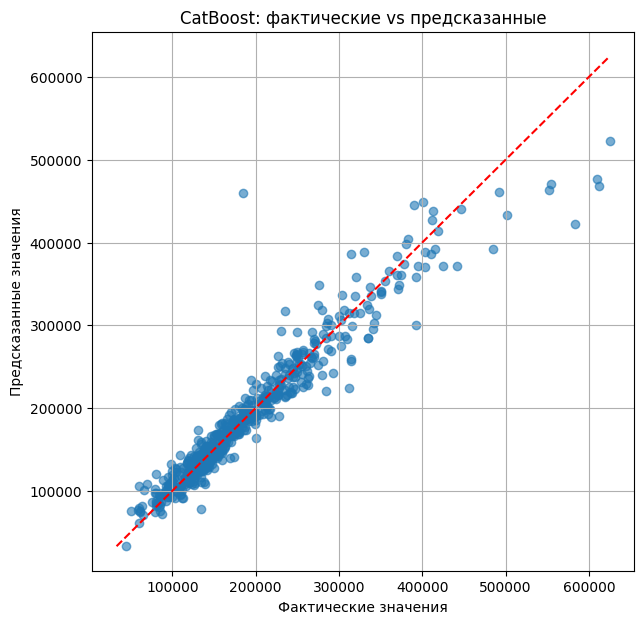

In [22]:
#14. Scatter-график: фактические значения против предсказанных (CatBoost)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_catboost, alpha=0.6)

# Диагональная линия идеальных предсказаний
min_val = min(y_test.min(), y_pred_catboost.min())
max_val = max(y_test.max(), y_pred_catboost.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Фактические значения")
plt.ylabel("Предсказанные значения")
plt.title("CatBoost: фактические vs предсказанные")
plt.grid(True)
plt.show()


Этот график показывает, насколько хорошо модель CatBoost предсказывает цену дома.
Каждая точка — одно наблюдение.
Чем ближе точки к красной диагонали, тем точнее модель попала в реальную цену.

График показывает, что модель CatBoost очень хорошо совпадает с реальными значениями: точки плотно лежат вдоль диагональной линии, что говорит о высокой точности предсказаний. Отклонения есть, но они небольшие и встречаются в основном у более дорогих домов, где разброс цен сам по себе выше.

Если сравнить scatter-график CatBoost с графиком MLP, видно, что CatBoost предсказывает цены точнее и стабильнее.

У CatBoost точки лежат ближе к диагонали, особенно в диапазоне средних цен, где сосредоточено большинство объектов. У MLP разброс заметно больше, особенно в верхней части графика: нейронная сеть чаще недооценивает или переоценивает дорогие дома. CatBoost же даёт более плотное облако точек и меньше крупных ошибок.

In [23]:
#Теперь, CatBoost автоматически отобразит кривую обучения, а также можно будет сохранить метрики:
history = catboost_model.get_evals_result()

Здесь я использую встроенные инструменты CatBoost, чтобы посмотреть, как менялась ошибка модели во время обучения.

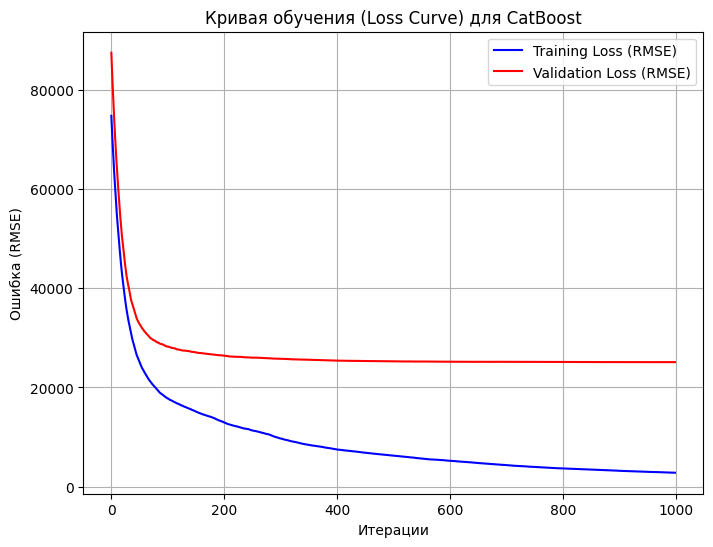

In [24]:
# 15. Кривая обучения (Loss Curve)
# CatBoost имеет атрибут loss_curve_, который содержит информацию о значениях потерь на каждом шаге.
train_loss = history['learn']['RMSE']
test_loss = history['validation']['RMSE']

plt.figure(figsize=(8, 6))
plt.plot(train_loss, label='Training Loss (RMSE)', color='blue')
plt.plot(test_loss, label='Validation Loss (RMSE)', color='red')
plt.title("Кривая обучения (Loss Curve) для CatBoost")
plt.xlabel("Итерации")
plt.ylabel("Ошибка (RMSE)")
plt.legend()
plt.grid(True)
plt.show()

По графику видно, как быстро модель учится, нет ли переобучения и на каком количестве итераций качество стабилизируется.

Кривая обучения модели CatBoost показывает, что ошибка на обучающих данных быстро снижается, в то время как ошибка на валидационных данных стабилизируется, что может указывать на некоторое переобучение. Однако, в целом, модель хорошо обучена, и её ошибка на обеих выборках постепенно уменьшается, что подтверждает её эффективность в задаче предсказания.

1. MLP (Многослойный перцептрон):

R² = 0.898 — модель объясняет 89.8% вариации в данных.
MAE = 16,042.06 — в среднем предсказания отличаются от реальных значений на 16,042.06.
RMSE = 28,889.33 — модель имеет достаточно большие ошибки в некоторых случаях.

2. CatBoost:

R² = 0.921 — модель объясняет 92.1% вариации в данных, что значительно выше, чем у MLP.
MAE = 14,386.34 — ошибка предсказания на 10% меньше, чем у MLP, что делает модель более точной.
RMSE = 25,092.04 — ошибки также меньше, чем у MLP, что свидетельствует о большей точности предсказаний.

Сравнение результатов показывает, что CatBoost заметно точнее и стабильнее, чем MLP, при предсказании стоимости домов. На scatter-графике точки CatBoost гораздо плотнее лежат вдоль линии идеального совпадения, тогда как MLP даёт больший разброс, особенно в области высоких цен. Метрики качества также подтверждают преимущество CatBoost: у него меньше средняя ошибка и лучше общая точность модели.

CatBoost оказался лучше, потому что он естественно приспособлен для табличных данных и категорий, а MLP — нет.

